## PythonからMeCab（形態素解析エンジン）をインストール
### 日本語の形態素解析が可能になる

In [22]:
pip install mecab-python3

Note: you may need to restart the kernel to use updated packages.


## MeCabの辞書（UniDicの軽量版）をインストール

In [24]:
pip install unidic-lite

Note: you may need to restart the kernel to use updated packages.


## wordcloudのライブラリーからWordCloudクラスをインポート
### このクラスは、テキストデータ（文章）を解析して単語の出現頻度に応じた大きさで雲状に配置した図（WordCloud）を作成できる
## maltplotで代表的なグラフ描画ライブラリーをインストール

In [26]:
from wordcloud import WordCloud # WordCloud作成するクラスインポート
import matplotlib.pyplot as plt # WordCloudを画面に表示するためのツールインストール

## MeCabを『分かち書きモード』で動かし、日本語文を単語ごとに区切り、Pythonリストとして扱える形に

In [28]:
import MeCab
wakati = MeCab.Tagger("-Owakati")
wakati.parse("すもももももももものうち").split()

['すもも', 'も', 'もも', 'も', 'もも', 'の', 'うち']

## neko.txtファイルを解析し、名刺の出現頻度をもとに日本語のWordCloudを描くプログラム

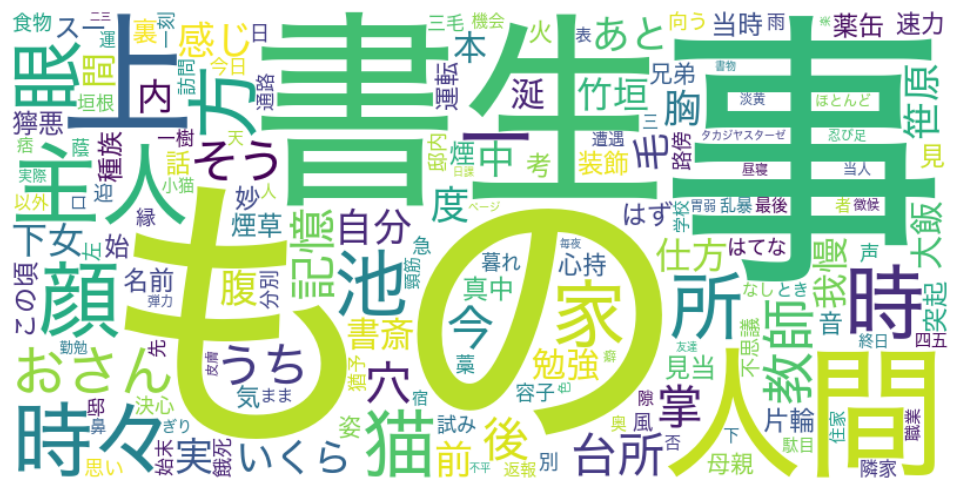

In [45]:
import matplotlib.pyplot as plt
from collections import Counter

####################################################################
# ①入力する日本語テキスト
####################################################################
with open("./data/neko.txt", "r", encoding = "utf-8")as file:
    text = file.read()

####################################################################
# ②MeCabで名詞を抽出
####################################################################
tagger = MeCab.Tagger()
node = tagger.parseToNode(text)

words = []
while node:
    features = node.feature.split(",")
    if features[0] == "名詞":
        words.append(node.surface)
    node = node.next

####################################################################
# ③単語頻度の計算
####################################################################
freq = Counter(words)

####################################################################
# ④フォントパス(macOS用)※必要に応じて変更
####################################################################
font_path = "/System/Library/Fonts/ヒラギノ角ゴシック W4.ttc"

####################################################################
# ⑤　ワードクラウドの生成と表示
####################################################################
wordcloud = WordCloud(
    font_path = font_path,
    background_color = "white",
    width = 800,
    height = 400
).generate_from_frequencies(freq)

plt.figure(figsize = (10,5))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()